In [31]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [32]:
# Loading the dataset
data = pd.read_csv('wine.csv')
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [33]:
data = data.drop('Id', axis = 1)

In [34]:
print(data['quality'].unique())

[5 6 7 4 8 3]


In [35]:
X = data.drop('quality', axis = 1)
y = data['quality']

In [36]:
X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


In [37]:
quality_mapping = {3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5}
y = np.array([quality_mapping[val] for val in y])

In [38]:
# Creating Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [39]:
# Scaling the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print(X_train.shape)
print(X_train)

(914, 11)
[[ 0.1426802  -1.40273053  1.5096933  ... -0.09314751  0.56821234
   0.05661327]
 [ 0.96843134 -1.17920341  1.5096933  ... -1.07474038  0.4477703
   0.89445566]
 [ 0.3786091  -1.23508519  0.4833938  ...  0.56124774  0.20688622
   1.26683005]
 ...
 [-0.50612428 -1.01155806  0.32944888 ...  0.29948964 -0.33510296
   1.35992365]
 [-0.21121315  0.21784112  0.22681893 ... -0.15858703  0.20688622
  -0.87432272]
 [-0.44714205 -0.06156778  0.6886537  ... -0.35490561 -0.09421888
   1.26683005]]


In [42]:
## Building the ANN model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
model = Sequential([
    Dense(32, activation = 'relu', input_shape=(11,)),
    Dense(16, activation = 'relu'),
    Dense(6, activation = 'softmax')
])

In [46]:
model.save('my_wine_model.h5')

In [43]:
## Compiling the model
model.compile(optimizer = 'adam', loss='sparse_categorical_crossentropy', metrics = ['accuracy'])

In [44]:
## Training the model
history = model.fit(
    X_train, y_train,
    epochs = 100,
    batch_size = 32,
    validation_data = (X_test, y_test)
)

Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.3118 - loss: 1.6537 - val_accuracy: 0.4105 - val_loss: 1.5056
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4387 - loss: 1.4696 - val_accuracy: 0.5459 - val_loss: 1.3402
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5175 - loss: 1.3186 - val_accuracy: 0.5895 - val_loss: 1.1957
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5711 - loss: 1.1843 - val_accuracy: 0.6026 - val_loss: 1.0726
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5886 - loss: 1.0924 - val_accuracy: 0.6070 - val_loss: 1.0024
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6050 - loss: 1.0452 - val_accuracy: 0.6114 - val_loss: 0.9662
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6083 - loss: 1.0207 - val_accuracy: 0.6070 - val_loss: 0.9443
Epoch 8/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6127 - loss: 1.0032 - val_accuracy: 0.6114 -


Final Test Loss: 0.9487
Final Test Accuracy: 64.63%


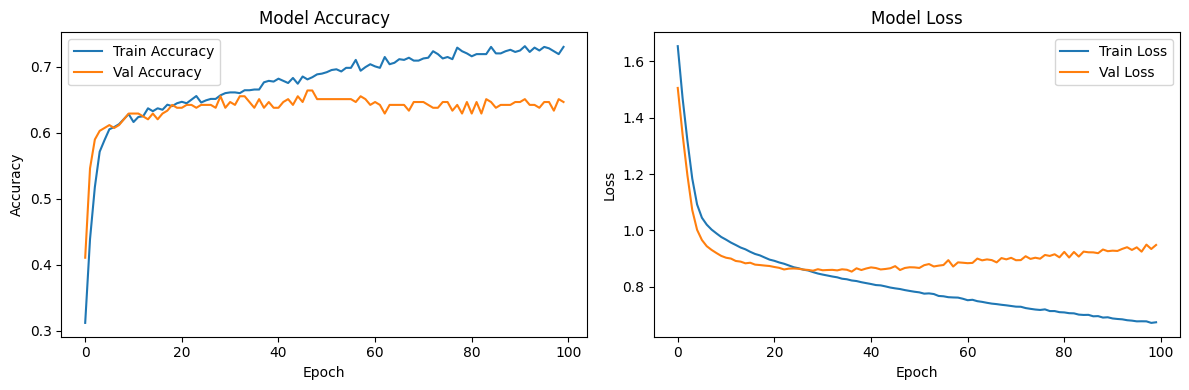

In [45]:
import matplotlib.pyplot as plt

# 1. Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nFinal Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")

# 2. Create a plot for Accuracy and Loss side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot Accuracy
ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Plot Loss
ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()